In [1]:
# ===================== 自动安装所有依赖包=====================
import importlib
import subprocess
import sys

required_packages = ["numpy", "pandas", "matplotlib", "seaborn", "scipy"]
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
print("✅ 所有依赖包已准备完成！")

✅ 所有依赖包已准备完成！


In [2]:
# =======================清除环境==================================

%reset -f
# =======================导入库==================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import warnings
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')

pd.set_option('mode.chained_assignment', None)

In [3]:

# ===================== 工作目录=====================
root_dir = r'.'
os.makedirs(root_dir, exist_ok=True)
os.chdir(root_dir)

In [4]:

# 图片保存目录
save_fig_dir = r' ./figure'
os.makedirs(save_fig_dir, exist_ok=True)
# ==========================================================================

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ===================== 数据读取路径=====================
df_site = pd.read_csv(r" ./data\sites_meta_info.csv", index_col=0)
df_SNR = pd.read_csv(r" ./data\beta_SNR_results.csv", index_col=0)
df_delta_Y = pd.read_csv(r" ./data\delta_Y_CO2_results.csv", index_col=0)

✅ 图片已保存到：
 ./figure\Fig2.png


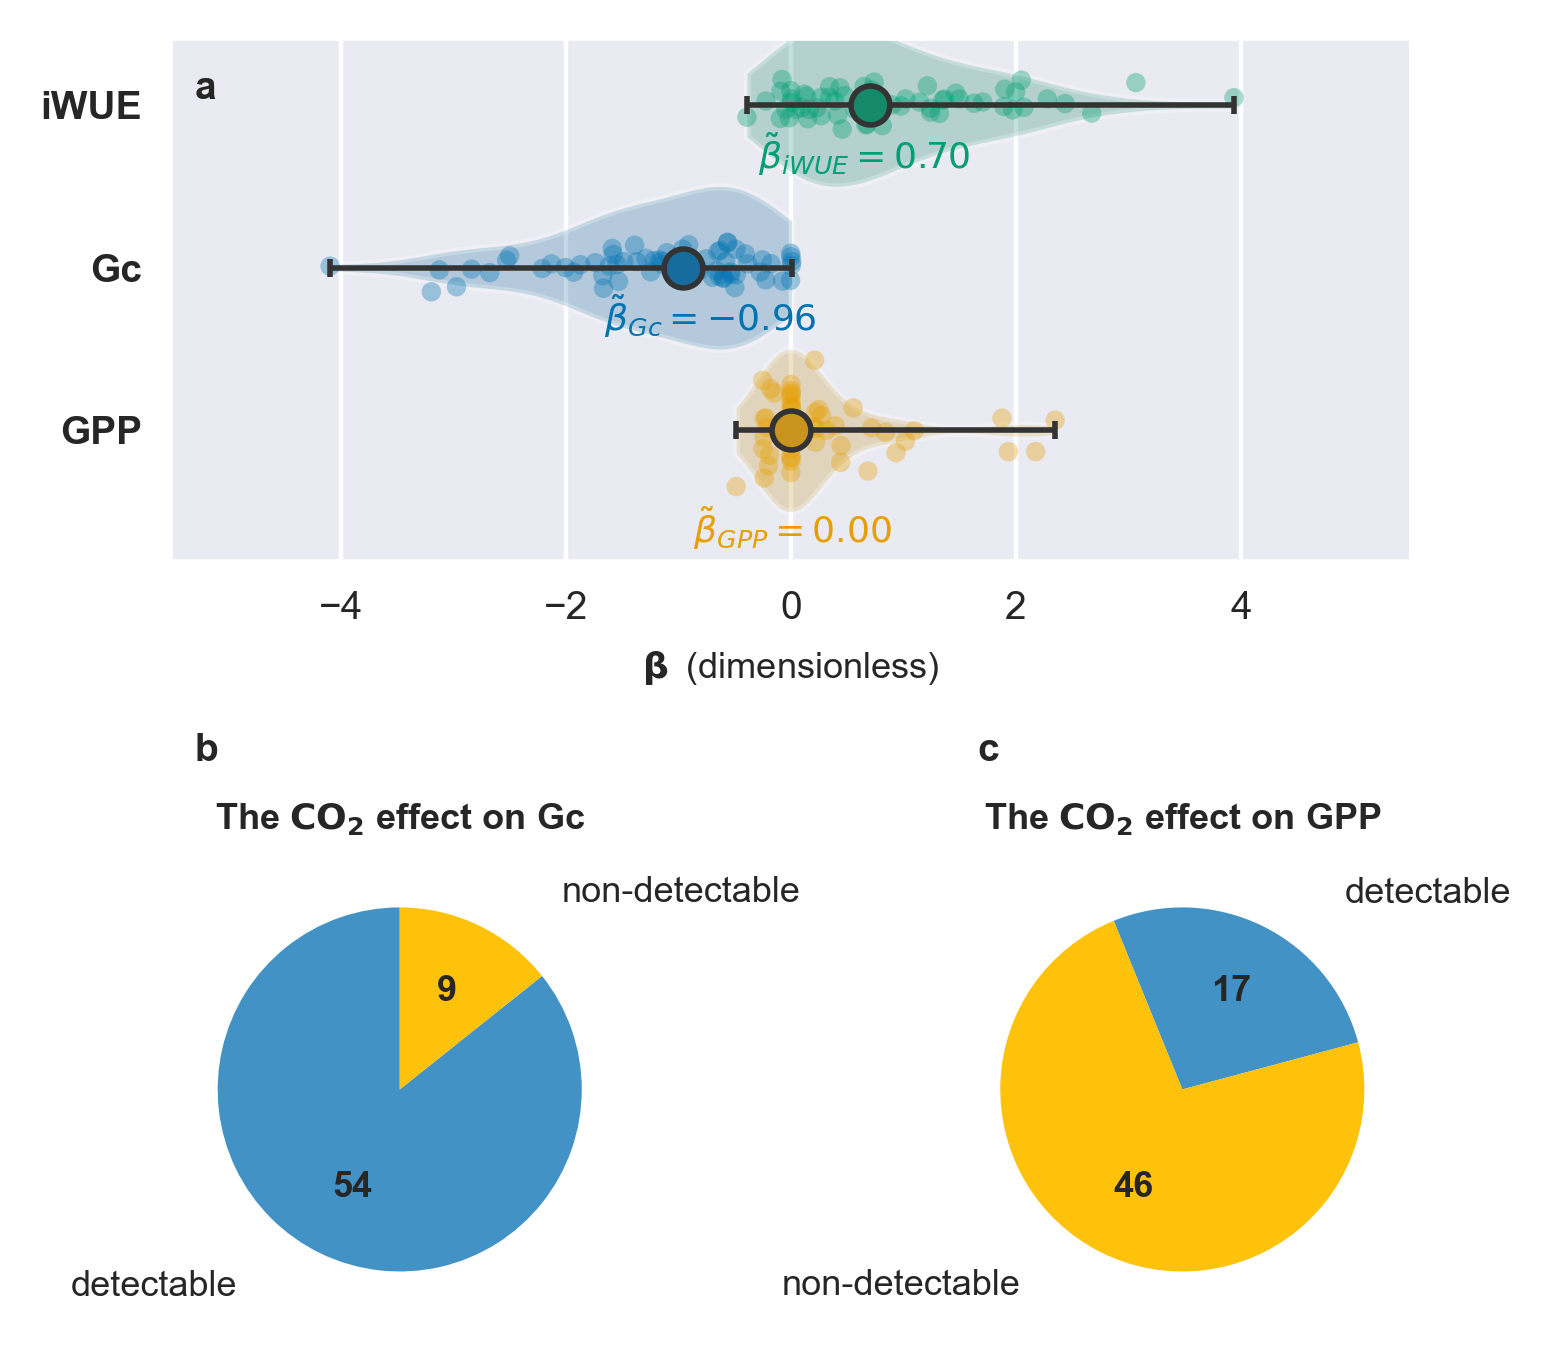

In [5]:
# ======================================================================

## Fig. 2: pie chart & beta distribution
blue_c = '#0072B2'
brown_c = '#E69F00'
green_c = '#009E73'

order_gen = ['detectable', 'non-detectable']
color_dic = {'Gc': blue_c, 'GPP': brown_c, 'iWUE': green_c, 'Gs': blue_c}
beta_values = {
    'Gc': df_SNR['Gc_beta'].values,
    'GPP': df_SNR['GPP_beta'].values,
    'iWUE': df_SNR['iWUE_beta'].values
}

data = [beta_values['GPP'], beta_values['Gc'], beta_values['iWUE']]

data = pd.DataFrame(beta_values)
melted_data = data.melt(var_name='Variable', value_name='Beta Value')

fontsize = 6.5

plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 800
plt.rcParams['font.size'] = fontsize
plt.rcParams['font.family'] = 'Arial'


def pie_chart(data, fig, ax, colors, startangle, order_gen, a, b, fontsize=fontsize):
    wedges, texts, _ = ax.pie(data, autopct=lambda x: '{:.0f}'.format(x * df_SNR.shape[0] / 100),
                              wedgeprops={"alpha": 1, "edgecolor": "none", 'linewidth': 0.5, 'antialiased': True},
                              textprops={'size': fontsize, 'weight': 'bold'}, colors=colors, startangle=startangle)

    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="none")
    kw = dict(arrowprops=dict(arrowstyle="-", lw=0.5),
              bbox=bbox_props, zorder=0, va="center", fontsize=fontsize)

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1) / 2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(order_gen[i], xy=(x, y), xytext=(a * np.sign(x), b * y),
                    horizontalalignment=horizontalalignment, **kw)


width_old, height_old = 8.2, 7.5
width_new = 3.8
height_new = height_old / width_old * width_new

fig = plt.figure(figsize=(width_new, height_new), dpi=200)

shape = (2, 2)
ax_1 = plt.subplot2grid(shape, loc=(0, 0), colspan=2, rowspan=1)
ax_2 = plt.subplot2grid(shape, loc=(1, 0), colspan=1, rowspan=1)
ax_3 = plt.subplot2grid(shape, loc=(1, 1), colspan=1, rowspan=1)

blue_pie, red_pie = '#4292C5', '#FFC20A'

df_group = df_SNR.groupby('Gc_cluster').count().iloc[:, 0]
data = df_group.loc[order_gen].values
pie_chart(data, fig, ax_2, [blue_pie, red_pie], 90, order_gen, 0.89, 1.2)

df_group = df_SNR.groupby('GPP_cluster').count().iloc[:, 0]
data = df_group.loc[order_gen].values
pie_chart(data, fig, ax_3, [blue_pie, red_pie], 15, order_gen, 0.89, 1.2)

targets = ['Gc', 'GPP']
for i, ax in enumerate([ax_2, ax_3]):
    ax.set_ylabel('')
    ax.set_title(f'The $\\mathbf{{CO_2}}$ effect on {targets[i]}',
                 fontweight='bold', fontsize=6.5)

violin_order = ['iWUE', 'Gc', 'GPP']
violin_parts = sns.violinplot(x='Beta Value', y='Variable',
                              data=melted_data, scale='area',
                              palette=color_dic, cut=0,
                              order=violin_order, ax=ax_1, inner=None, width=1, zorder=1)

for i, violin in enumerate(violin_parts.collections):
    violin.set_edgecolor(None)
    violin.set_alpha(0.25)

size = 3.5
alpha = 0.35
jitter_strength = {'iWUE': 0.08, 'Gc': 0.08, 'GPP': 0.16}
seeds = [42, 42, 46]

for i_v, variable in enumerate(violin_order):
    x_data = melted_data[melted_data['Variable'] == variable]['Beta Value']
    np.random.seed(seeds[i_v])
    y_data = np.random.normal(loc=violin_order.index(variable), scale=jitter_strength[variable], size=len(x_data))
    ax_1.scatter(x_data, y_data, color=color_dic[variable], s=size ** 2, alpha=alpha, zorder=10, edgecolors='none')

quantiles = melted_data.groupby('Variable')['Beta Value'].quantile([0, 0.5, 1])
iqr_values = quantiles.unstack()

for i, var in enumerate(violin_order):
    q1 = iqr_values.loc[var, 0]
    median = iqr_values.loc[var, 0.5]
    q3 = iqr_values.loc[var, 1]
    violin_color = violin_parts.collections[i].get_facecolor().flatten()

    linecolor = (0.2, 0.2, 0.2, 1)
    edgewidth = 1
    ax_1.errorbar(x=median, y=i, xerr=[[median - q1], [q3 - median]], fmt='o', color=violin_color,
                  ecolor=linecolor,
                  elinewidth=edgewidth,
                  capthick=2,
                  capsize=1.7,
                  markersize=7,
                  alpha=1,
                  markeredgewidth=edgewidth,
                  markeredgecolor=linecolor,
                  zorder=10)

x_dic = {'iWUE': -0.05, 'Gc': 0.25, 'GPP': 0.01}
h_dic = {'iWUE': 0.3, 'Gc': 1.3, 'GPP': 2.6}

for var in ['iWUE', 'Gc', 'GPP']:
    median = df_SNR[f'{var}_beta'].median()
    ax_1.text(median + x_dic[var], h_dic[var], r'$\tilde \beta_{%s}=%.2f$' % (var, median),
              color=color_dic[var],
              verticalalignment='center',
              horizontalalignment='center',
              fontsize=fontsize)

ax_1.set_ylabel('')
ax_1.set_xlabel(r'$\mathbf{\beta \:}$ (dimensionless)', fontsize=fontsize)
ax_1.set_ylim([2.8, -0.4])
ax_1.set_xlim([-5.5, 5.5])
ax_1.tick_params(axis='x', labelsize=fontsize + 0.5)

for label in ax_1.get_yticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(fontsize + 0.5)

for ax in [ax_1, ax_2, ax_3]:
    ax.tick_params(width=0.3, length=2)
    for spine in ax.spines.values():
        spine.set_linewidth(0.3)

ax_1.annotate('a', xy=(4, 83), xycoords='axes points', fontweight='bold', fontsize=fontsize + 0.5)
ax_2.annotate('b', xy=(4, 100), xycoords='axes points', fontweight='bold', fontsize=fontsize + 0.5)
ax_3.annotate('c', xy=(4, 100), xycoords='axes points', fontweight='bold', fontsize=fontsize + 0.5)

plt.tight_layout()

# ===================== 自动保存图片 =====================
save_path = os.path.join(save_fig_dir, 'Fig2.png')
plt.savefig(save_path, dpi=800, bbox_inches='tight')
print(f"✅ 图片已保存到：\n{save_path}")
# ================================================================

plt.show()